In [1]:
import tensorflow
tensorflow.__version__

'2.19.0'

In [2]:
#Install DeepFace Library
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.5 MB/s eta 0:00:00


In [3]:
%pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.4 MB/s eta 0:00:00


In [4]:
#Import DeepFace, CV2 and Matplotlib libraries
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt

25-10-04 00:57:41 - Directory /root/.deepface has been created
25-10-04 00:57:41 - Directory /root/.deepface/weights has been created


In [5]:
#Download a file
!curl -L https://i.imgur.com/JynpBOr.jpeg -o img.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2152k  100 2152k    0     0  4522k      0 --:--:-- --:--:-- --:--:-- 4530k


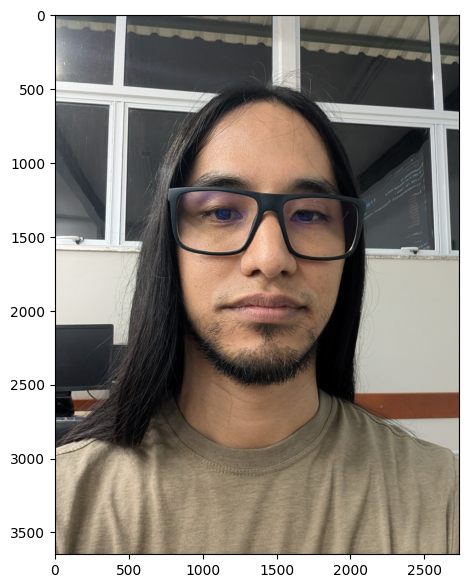

In [6]:
check_img = cv2.imread('img.jpg')
plt.figure(figsize=(7,7))
plt.imshow(check_img[:, :, ::-1])

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
25-10-04 00:57:55 - 🔗 yolov8n-face.pt will be downloaded from https://drive.google.com/uc?id=1qcr9DbgsX3ryrz2uU8w4Xm3cOrRywXqb to /root/.deepface/weights/yolov8n-face.pt...


Downloading...
From: https://drive.google.com/uc?id=1qcr9DbgsX3ryrz2uU8w4Xm3cOrRywXqb
To: /root/.deepface/weights/yolov8n-face.pt
100%|██████████| 6.39M/6.39M [00:00<00:00, 36.9MB/s]


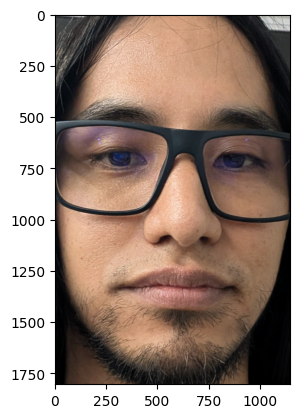

In [7]:
detected_faces = DeepFace.extract_faces(img_path=check_img, detector_backend='yolov8', align=True)

cropped_faces = []
face_info = detected_faces[0]
x, y, w, h = face_info['facial_area']['x'], face_info['facial_area']['y'], \
                  face_info['facial_area']['w'], face_info['facial_area']['h']

# Crop the face from the original image
cropped_face = check_img[y:y+h, x:x+w]
cropped_faces.append(cropped_face)


# Invert to bgr
plt.imshow(cropped_face[:,:,::-1])


In [8]:
#DeepFace analyse the uploaded image
analyze_face = DeepFace.analyze(cropped_face[:,:,::-1])

Action: emotion:   0%|          | 0/4 [00:00<?, ?it/s]

25-10-04 00:58:09 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5

100%|██████████| 5.98M/5.98M [00:00<00:00, 100MB/s]
Action: age:  25%|██▌       | 1/4 [00:00<00:02,  1.32it/s]    

25-10-04 00:58:12 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5

  0%|          | 0.00/539M [00:00<?, ?B/s]
  2%|▏         | 8.39M/539M [00:00<00:06, 79.9MB/s]
  3%|▎         | 16.8M/539M [00:00<00:08, 62.5MB/s]
  4%|▍         | 23.6M/539M [00:00<00:08, 59.9MB/s]
  6%|▌         | 33.0M/539M [00:00<00:07, 71.6MB/s]
  9%|▉         | 50.3M/539M [00:00<00:04, 104MB/s] 
 12%|█▏        | 63.4M/539M [00:00<00:04, 103MB/s]
 14%|█▍        | 78.1M/539M [00:00<00:04, 107MB/s]
 17%|█▋        | 89.1M/539M [00:00<00:04, 95.7MB/s]
 19%|█▊        | 100M/539M [00:01<00:04, 99.2MB/s] 
 21%|██        | 114M/539M [00:01<00:03, 109MB/s] 
 23%|██▎       | 126M/539M [00:01<00:03, 104MB/s]
 25%|██▌       | 137M/539M [00:01<00:04, 86.8MB/s]
 28%|██▊       | 152M/539M [00:01<00:03, 101MB/s] 
 31%|███       | 168M/539M [00:01<00:03, 105MB/s]
 34%|███▍      | 184M/539M [00:01<00:03, 117MB/s]
 36%|███▋      | 197M/539M [0

25-10-04 00:58:23 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/weights/gender_model_weights.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  2%|▏         | 11.0M/537M [00:00<00:05, 87.9MB/s]
  4%|▍         | 21.5M/537M [00:00<00:05, 95.5MB/s]
  6%|▌         | 31.5M/537M [00:00<00:05, 92.7MB/s]
  8%|▊         | 40.9M/537M [00:00<00:06, 72.7MB/s]
  9%|▉         | 49.8M/537M [00:00<00:06, 77.4MB/s]
 11%|█         | 58.2M/537M [00:00<00:06, 78.7MB/s]
 13%|█▎        | 70.3M/537M [00:00<00:05, 89.8MB/s]
 15%|█▌        | 81.3M/537M [00:00<00:04, 95.2MB/s]
 17%|█▋        | 91.2M/537M [00:01<00:04, 93.0MB/s]
 19%|█▉        | 101M/537M [00:01<00:04, 91.8MB/s] 
 21%|██        | 111M/537M [00:01<00:05, 80.2MB/s]
 22%|██▏       | 119M/537M [00:01<00:05, 73.4MB/s]
 24%|██▎       | 127M/537M [00:01<00:05, 73.8MB/s]
 25%|██▌       | 137M/537M [00:01<00:05, 77.3MB/s]
 27%|██▋       | 147M/537M [00:01<00:05, 77.9MB/s]
 29%|██▉       | 

25-10-04 00:58:36 - 🔗 race_model_single_batch.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5 to /root/.deepface/weights/race_model_single_batch.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5
To: /root/.deepface/weights/race_model_single_batch.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  2%|▏         | 11.0M/537M [00:00<00:07, 74.5MB/s]
  5%|▍         | 24.6M/537M [00:00<00:04, 103MB/s] 
  7%|▋         | 37.2M/537M [00:00<00:04, 112MB/s]
  9%|▉         | 49.3M/537M [00:00<00:04, 112MB/s]
 12%|█▏        | 63.4M/537M [00:00<00:04, 105MB/s]
 14%|█▍        | 76.5M/537M [00:00<00:04, 112MB/s]
 17%|█▋        | 93.3M/537M [00:00<00:03, 128MB/s]
 20%|█▉        | 107M/537M [00:00<00:03, 117MB/s] 
 22%|██▏       | 120M/537M [00:01<00:03, 117MB/s]
 25%|██▌       | 137M/537M [00:01<00:03, 121MB/s]
 29%|██▊       | 154M/537M [00:01<00:02, 134MB/s]
 31%|███▏      | 168M/537M [00:01<00:03, 123MB/s]
 34%|███▍      | 184M/537M [00:01<00:02, 130MB/s]
 37%|███▋      | 198M/537M [00:01<00:02, 134MB/s]
 40%|███▉      | 212M/537M [00:01<00:03, 99.4MB/s]
 43%|████▎     | 231M/537

In [9]:
#Print all analysis of an image
analyze_face

[{'emotion': {'angry': np.float32(0.20595942),
   'disgust': np.float32(0.06010214),
   'fear': np.float32(73.496056),
   'happy': np.float32(3.3454797),
   'sad': np.float32(0.12498058),
   'surprise': np.float32(2.912152),
   'neutral': np.float32(19.855272)},
  'dominant_emotion': 'fear',
  'region': {'x': 0,
   'y': 77,
   'w': 1145,
   'h': 1622,
   'left_eye': (889, 711),
   'right_eye': (285, 705)},
  'face_confidence': 0.92,
  'age': 26,
  'gender': {'Woman': np.float32(1.3296546), 'Man': np.float32(98.67034)},
  'dominant_gender': 'Man',
  'race': {'asian': np.float32(42.779816),
   'indian': np.float32(11.665752),
   'black': np.float32(4.7628417),
   'white': np.float32(7.2968507),
   'middle eastern': np.float32(3.899548),
   'latino hispanic': np.float32(29.595192)},
  'dominant_race': 'asian'}]

In [10]:
#Let's print only emotion from the image
analyze_face[0]['dominant_emotion']

'fear'

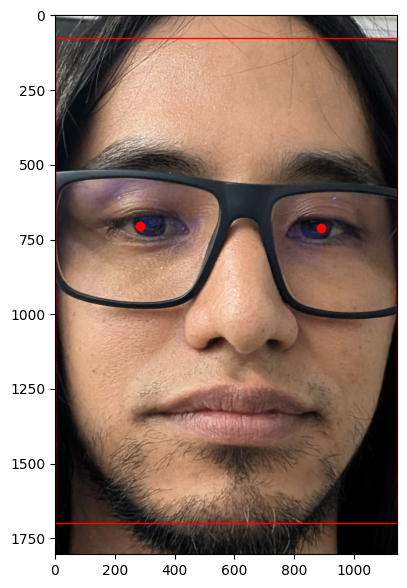

In [11]:
import matplotlib.patches as patches


# Imprime imagem
plt.figure(figsize=(7,7))
plt.imshow(cropped_face[:, :, ::-1])

# Adiciona posição dos olhos
plt.scatter(analyze_face[0]['region']['left_eye'][0], analyze_face[0]['region']['left_eye'][1], color='red')
plt.scatter(analyze_face[0]['region']['right_eye'][0], analyze_face[0]['region']['right_eye'][1], color='red')

# Posição do rosto
rect = patches.Rectangle((analyze_face[0]['region']['x'], analyze_face[0]['region']['y']), analyze_face[0]['region']['w'], analyze_face[0]['region']['h'], linewidth=1, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect)



# Modelos

Esses são os dois modelos mais famosos disponíveis

## [VGG-Face](https://www.robots.ox.ac.uk/~vgg/publications/2015/Parkhi15/)

[VGG](https://paperswithcode.com/method/vgg) é uma famosa rede CNN de 2014.
Essa aqui foi treinada no conjunto de dados LFW (labelled faces in the wild)
que contém 13.233 imagens de rostos da internet de 5.749 pessoas diferentes,
sendo que 1.680 destas possuem duas ou mais imagens.

<center>
<img src="https://production-media.paperswithcode.com/methods/vgg_7mT4DML.png">
</center>

Aqui tiramos a última camada de 1000 classes e ficamos com um `embedding` de 4096 valores.

## [FaceNet](https://arxiv.org/abs/1503.03832)


<center>
<img src="https://miro.medium.com/v2/resize:fit:1400/1*PaxDM5QUt8ZzUgCo2dzf4w.png">
</center>

A `FaceNet` também utiliza uma CNN como base, o que ela inovou foi na forma como a rede é treinada. Em vez de treinar a rede para classificar pessoas genéricas em classes, a `FaceNet` pode ser treinada diretamente nas pessoas de interesse sem precisar ser no modelo `classificação`.

Lembre que para treinar basta ter uma função de `Loss`. Nesse eles rodam a rede três vezes:

1. a âncora (A): foto de referência da pessoa
1. positiva (P): outra foto da **mesma pessoa** (de preferência bem diferente da original, mais nova, mais velha, outro corte de cabelo, barba, óculos, etc.).
1. negativa (N): foto de **outra pessoa**

Basta calcular a diferença entre a âncora e as duas outras fotos:

1. $ D(A, P) $: diferença entre âncora e positiva
1. $ D(A, N) $ : diferença entre âncora e negativa

A perda final é definida como:

$$ Loss =  D(A, P) - D(A, N) $$

Isso significa que se âncora e positiva ($ D(A, P) $) forem idênticas, a perda seria 0, mas se a diferença entre a âncora e negativa ($ D(A, N) $) for 1, a perda vai ser $ 0 - 1 = -1 $. Ou seja é possível ter perda inclusive negativa.

Lembre `Loss` quanto menor é melhor, então quanto mais negativo melhor, o que faz sentido, pois quanto mais iguais âncora e positiva forem $ D(A, P) \approx 0 $, e quanto mais diferentes âncora e negativa forem será melhor.

Na prática se limita o quão diferente os dois podem ser para que não haja uma diferenciação artificial e não haja o **sobreajuste**.

Assim evitamos ir para o negativo infinitamente usando a fórmula:

$$ Loss = max(0, D(A, P) - D(A, N) + \alpha) $$

Aqui, $ \alpha $ é a margem máxima negativa de $ D(A,P) - D(A, N) $, abaixo disso a função $ max(0,\ \dots) $, vai considerar a perda como 0.

In [12]:
!pip uninstall -y keras

Found existing installation: keras 3.10.0
Uninstalling keras-3.10.0:
  Successfully uninstalled keras-3.10.0


In [13]:
# Force restart session
import IPython

IPython.Application.instance().kernel.do_shutdown(True)


{'status': 'ok', 'restart': True}

In [2]:
#Import DeepFace, CV2 and Matplotlib libraries
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt

In [3]:
models = [
  "VGG-Face",
  "Facenet",
  "Facenet512",
  "OpenFace",
  "DeepFace",
  "DeepID",
  "ArcFace",
  "Dlib",
  "SFace",
  "GhostFaceNet",
]

the_model = 'ArcFace'

In [4]:
# Baixar

!wget https://github.com/caiohamamuraIFSP/2024FIC_AI/raw/refs/heads/main/bd.zip

# Descompactar

!unzip -o bd.zip

--2025-10-04 00:59:14--  https://github.com/caiohamamuraIFSP/2024FIC_AI/raw/refs/heads/main/bd.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/caiohamamuraIFSP/2024FIC_AI/refs/heads/main/bd.zip [following]
--2025-10-04 00:59:15--  https://raw.githubusercontent.com/caiohamamuraIFSP/2024FIC_AI/refs/heads/main/bd.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2550380 (2.4M) [application/zip]
Saving to: ‘bd.zip’

bd.zip              100%[===================>]   2.43M  --.-KB/s    in 0.05s   

2025-10-04 00:59:15 (49.0 MB/s) - ‘bd.zip’ saved [2550380/2550380]

Archive:  bd.zip
   creating: a

In [5]:
import os

# Import path
from pathlib import Path


imgs1 = [Path('bd') / ii for ii in  os.listdir('bd')  if ii.endswith('.jpg')]
imgs2 = [Path('achar') / ii for ii in os.listdir('achar')]

imgs = imgs1 + imgs2

In [6]:
backends = [
  'opencv',
  'ssd',
  'dlib',
  'mtcnn',
  'fastmtcnn',
  'retinaface',
  'mediapipe',
  'yolov8',
  'yunet',
  'centerface',
]

alignment_modes = [True, False]

In [7]:
# DeepFace.find vai verificar se encontra o rosto na base
findings = {}

for ii in imgs2:
    findings[ii] = DeepFace.find(
        img_path = ii,
        db_path = "./bd",
        model_name = the_model,
        detector_backend=backends[7],
    )


25-10-04 00:59:15 - Found 7 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   0%|          | 0/7 [00:00<?, ?it/s]

25-10-04 00:59:27 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to /root/.deepface/weights/arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: /root/.deepface/weights/arcface_weights.h5

  0%|          | 0.00/137M [00:00<?, ?B/s]
  5%|▌         | 7.34M/137M [00:00<00:01, 72.9MB/s]
 12%|█▏        | 16.8M/137M [00:00<00:01, 85.1MB/s]
 19%|█▊        | 25.7M/137M [00:00<00:01, 67.8MB/s]
 24%|██▍       | 33.0M/137M [00:00<00:01, 68.9MB/s]
 31%|███▏      | 43.0M/137M [00:00<00:01, 78.6MB/s]
 37%|███▋      | 51.4M/137M [00:00<00:01, 44.6MB/s]
 42%|████▏     | 57.7M/137M [00:01<00:01, 43.4MB/s]
 46%|████▋     | 63.4M/137M [00:01<00:01, 45.5MB/s]
 54%|█████▎    | 73.4M/137M [00:01<00:01, 57.3MB/s]
 59%|█████▊    | 80.2M/137M [00:01<00:00, 59.7MB/s]
 64%|██████▎   | 87.0M/137M [00:01<00:00, 57.3MB/s]
 71%|███████   | 97.5M/137M [00:01<00:00, 68.8MB/s]
 78%|███████▊  | 107M/137M [00:01<00:00, 75.1MB/s] 
 86%|████████▌ | 118M/137M [00:01<00:00, 84.1MB/s]
100%|██████████| 137M/137M [00:02<00:00, 66.1MB/s]
Finding representations:

25-10-04 00:59:36 - There are now 7 representations in ds_model_arcface_detector_yolov8_aligned_normalization_base_expand_0.pkl
25-10-04 00:59:36 - Searching achar/marcio1.jpg in 7 length datastore
25-10-04 00:59:36 - find function duration 21.06368112564087 seconds
25-10-04 00:59:37 - Searching achar/caio3.jpg in 7 length datastore
25-10-04 00:59:37 - find function duration 0.5121908187866211 seconds
25-10-04 00:59:37 - Searching achar/daniel2.jpg in 7 length datastore
25-10-04 00:59:37 - find function duration 0.5629656314849854 seconds
25-10-04 00:59:38 - Searching achar/takeshi2.jpg in 7 length datastore
25-10-04 00:59:38 - find function duration 0.5052118301391602 seconds
25-10-04 00:59:38 - Searching achar/shigueo.jpg in 7 length datastore
25-10-04 00:59:39 - find function duration 0.8580431938171387 seconds
25-10-04 00:59:39 - Searching achar/marcio2.jpg in 7 length datastore
25-10-04 00:59:39 - find function duration 0.5155055522918701 seconds
25-10-04 00:59:40 - Searching acha

In [8]:
# Find imgs in img2 database

for ii in imgs2:
    print(ii)
    print(findings[ii])
    print()
    found = DeepFace.find(
        img_path = ii,
        db_path = "./bd",
        model_name = the_model,
        detector_backend=backends[7],
    )
    if found:
        print(found)

achar/marcio1.jpg
[          identity                                      hash  target_x  \
0  ./bd/marcio.jpg  8cd293ee49e6583eb929eb6827c0ee971db663cb       600   
1  ./bd/daniel.jpg  b3395c74685ea0220a898eb7abd4f3e350cf2288       167   

   target_y  target_w  target_h  threshold  source_x  source_y  source_w  \
0       585       568       963       0.68        64        83       277   
1        81       250       374       0.68        64        83       277   

   source_h  distance  confidence  
0       386  0.596956        51.0  
1       386  0.620179        51.0  ]

25-10-04 00:59:42 - Searching achar/marcio1.jpg in 7 length datastore
25-10-04 00:59:43 - find function duration 0.7459211349487305 seconds
[          identity                                      hash  target_x  \
0  ./bd/marcio.jpg  8cd293ee49e6583eb929eb6827c0ee971db663cb       600   
1  ./bd/daniel.jpg  b3395c74685ea0220a898eb7abd4f3e350cf2288       167   

   target_y  target_w  target_h  threshold  source_x  s

In [9]:
embeddings = {}
imgs

for img in imgs:
    print(img)
    embedding = DeepFace.represent(
        img,
        model_name=the_model,
        detector_backend = backends[7],
        align = alignment_modes[0],
    )
    if embedding:
        embeddings[img.name] = embedding



bd/shigueo3.jpg
bd/shigueo2.jpg
bd/takeshi.jpg
bd/marcio.jpg
bd/daniel.jpg
bd/caio.jpg
bd/andre.jpg
achar/marcio1.jpg
achar/caio3.jpg
achar/daniel2.jpg
achar/takeshi2.jpg
achar/shigueo.jpg
achar/marcio2.jpg
achar/andre2.jpg
achar/caio2.jpg
achar/takeshi3.jpg
achar/andre1.jpg
achar/daniel1.jpg


In [10]:
import numpy as np

all_embeddings = np.array([embedding[0]['embedding'] for embedding in embeddings.values()])

In [11]:
# Calcule as diferenças entre os embeddings

from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(all_embeddings) / all_embeddings.shape[0]


In [12]:
# Imprimir distâncias apenas para diagonal superior

for ii in range(len(imgs)):
    for jj in range(len(imgs)):
        if ii < jj:
            print(imgs[ii], imgs[jj], distances[ii, jj])


bd/shigueo3.jpg bd/shigueo2.jpg 0.2271708128635228
bd/shigueo3.jpg bd/takeshi.jpg 0.35677393741897323
bd/shigueo3.jpg bd/marcio.jpg 0.2997964574395397
bd/shigueo3.jpg bd/daniel.jpg 0.29667999199193296
bd/shigueo3.jpg bd/caio.jpg 0.31108424546490065
bd/shigueo3.jpg bd/andre.jpg 0.28820396140174304
bd/shigueo3.jpg achar/marcio1.jpg 0.3750054408795329
bd/shigueo3.jpg achar/caio3.jpg 0.30008745541541126
bd/shigueo3.jpg achar/daniel2.jpg 0.3802098635424742
bd/shigueo3.jpg achar/takeshi2.jpg 0.3128734932124447
bd/shigueo3.jpg achar/shigueo.jpg 0.20473100145551296
bd/shigueo3.jpg achar/marcio2.jpg 0.28303943849951707
bd/shigueo3.jpg achar/andre2.jpg 0.2645122032099705
bd/shigueo3.jpg achar/caio2.jpg 0.33599966490166855
bd/shigueo3.jpg achar/takeshi3.jpg 0.35097768729759043
bd/shigueo3.jpg achar/andre1.jpg 0.26559367547693974
bd/shigueo3.jpg achar/daniel1.jpg 0.2940127372185531
bd/shigueo2.jpg bd/takeshi.jpg 0.290877550456335
bd/shigueo2.jpg bd/marcio.jpg 0.2286486669166678
bd/shigueo2.jpg bd/

In [13]:
for img in imgs2:
    print(img)
    embedding = DeepFace.represent(
        img,
        model_name=the_model,
        detector_backend = backends[7],
        align = alignment_modes[0],
    )
    if embedding:
        embeddings[img.name] = embedding


achar/marcio1.jpg
achar/caio3.jpg
achar/daniel2.jpg
achar/takeshi2.jpg
achar/shigueo.jpg
achar/marcio2.jpg
achar/andre2.jpg
achar/caio2.jpg
achar/takeshi3.jpg
achar/andre1.jpg
achar/daniel1.jpg


# Análise PCA

O vetor de `embeddings` do facenet tem 128 características. Não tem como vermos as diferenças
com tantos valores para cada imagem.

Uma opção é fazer a PCA (*Principal Component Analysis*), que utiliza de transformações matemáticas para extrair quais colunas possuem maior variabilidade única e despreza colunas que não dão informação (ou não tem variabilidade interna, ou ela é redundante com outra coluna existente).

In [14]:
all_embeddings.shape

(18, 512)

In [15]:
# Análise PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
res = pca.fit(all_embeddings.T)

import pandas as pd

pca_embeddings = pd.DataFrame(pca.components_.T)

pca_embeddings.columns = ['PC1', 'PC2']
pca_embeddings

,PC1,PC2
0,0.304379,0.458836
1,0.208730,0.298540
2,0.087488,-0.270188
3,0.158503,-0.049273
4,0.291185,-0.132133
5,0.112922,-0.104801
6,0.283764,0.266313
7,0.332751,-0.282475
8,0.151102,-0.110377
9,0.376518,-0.321857


In [16]:
# Variabilidade explicada pelos componentes

print(pca.explained_variance_ratio_)

[    0.25323     0.15119]


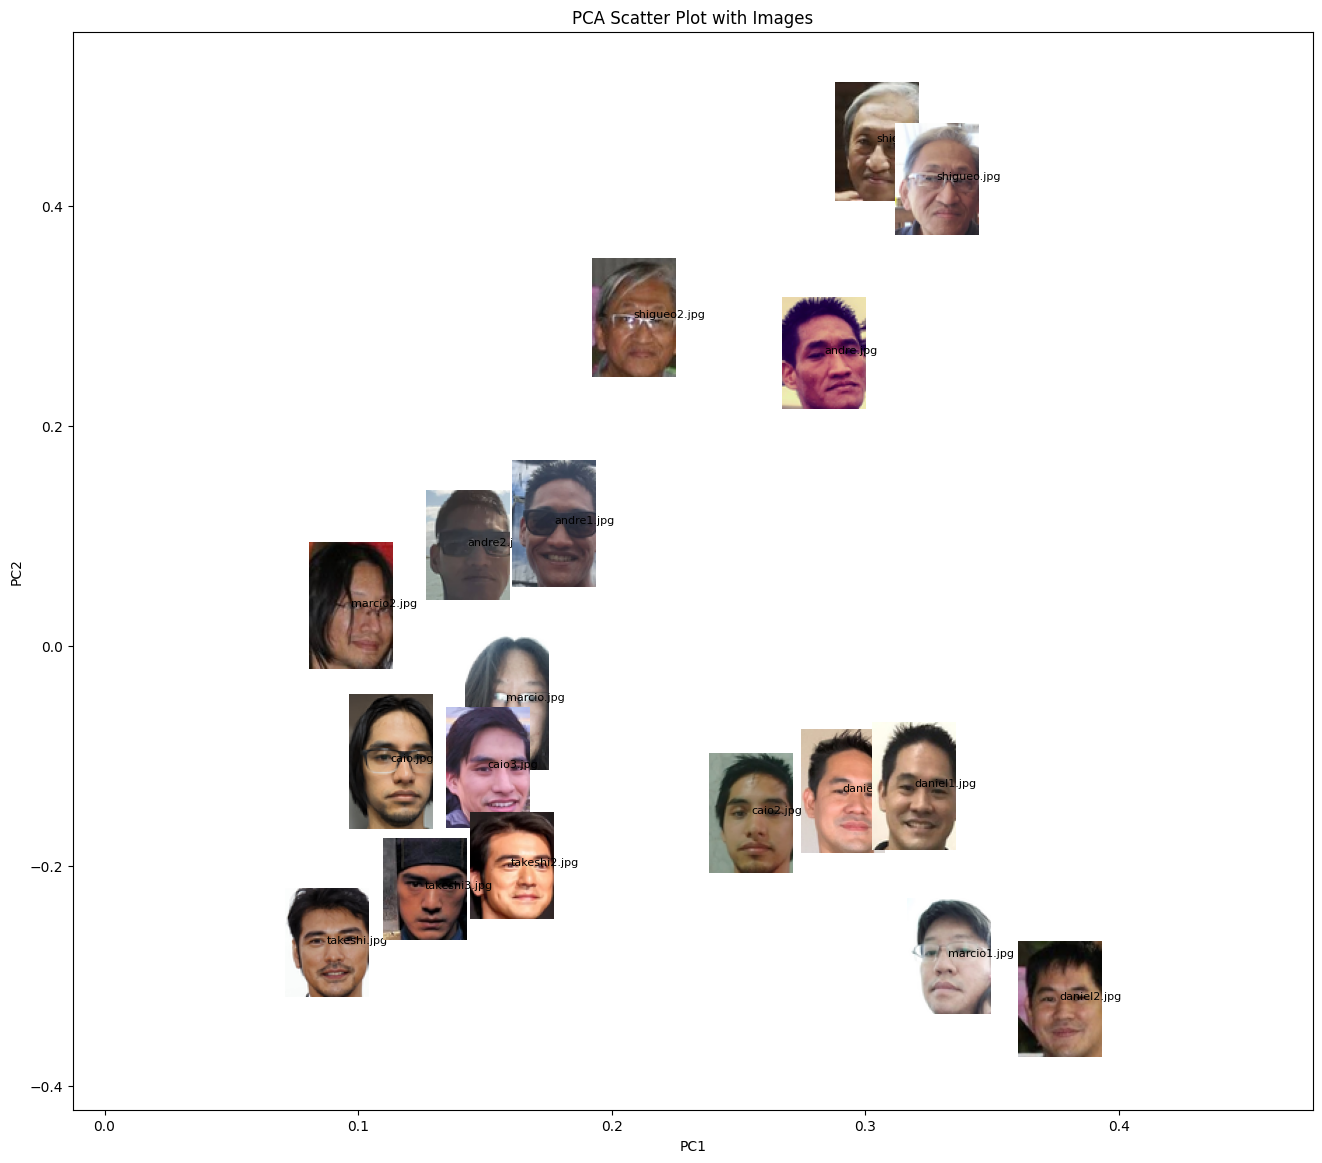

In [17]:
from matplotlib import pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
# Create a new figure
fig, ax = plt.subplots(figsize=(16, 14))

# Plot the PCA results with images
for i in range(pca_embeddings.shape[0]):
    img_path = imgs[i]
    img = Image.open(img_path)
    # Cut facial area
    x, y, w, h, _, _ = embeddings[img_path.name][0]['facial_area'].values()
    # Buffer 20% of the facial area
    x = max(0, x - w * 0.2)
    y = max(0, y - h * 0.2)
    w = min(img.width, w + w * 0.2)
    h = min(img.height, h + h * 0.2)
    img = img.crop((x, y, x + w, y + h))
    img = img.resize((60,img.height * 60 // img.width), resample = Image.Resampling.LANCZOS)
    imagebox = OffsetImage(img)
    ab = AnnotationBbox(imagebox, (pca_embeddings.loc[i,'PC1'], pca_embeddings.loc[i, 'PC2']), frameon=False)
    ax.add_artist(ab)

    # Add img_path.name on the bottom
    ax.text(pca_embeddings.loc[i,'PC1'], pca_embeddings.loc[i, 'PC2'], img_path.name, fontsize=8)


# Set labels and title
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA Scatter Plot with Images')
ax.set_xlim(min(pca_embeddings.iloc[:, 0]) - 0.1, max(pca_embeddings.iloc[:, 0]) + 0.1)
ax.set_ylim(min(pca_embeddings.iloc[:, 1]) - 0.1, max(pca_embeddings.iloc[:, 1]) + 0.1)

plt.show()

In [18]:
# Análise PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
res = pca.fit(all_embeddings.T)

import pandas as pd

pca_embeddings = pd.DataFrame(pca.components_.T)

pca_embeddings.columns = ['PC1', 'PC2', 'PC3']
pca_embeddings

,PC1,PC2,PC3
0,0.304379,0.458836,-0.085238
1,0.208730,0.298540,0.034933
2,0.087488,-0.270188,-0.310278
3,0.158503,-0.049273,0.057715
4,0.291185,-0.132133,0.221700
5,0.112922,-0.104801,-0.296601
6,0.283764,0.266313,-0.277247
7,0.332751,-0.282475,0.305962
8,0.151102,-0.110377,-0.254474
9,0.376518,-0.321857,0.423300


In [19]:
# Variabilidade explicada pelos componentes

print(pca.explained_variance_ratio_)

[    0.25323     0.15119      0.1265]


In [20]:
import re
classes = [re.sub(r'\d*.jpg', '', img.name) for img in imgs]

In [21]:
classes_unicas = np.unique(classes)
cmap = plt.cm.get_cmap('rainbow', len(classes_unicas))
colors = cmap(range(len(classes_unicas)))


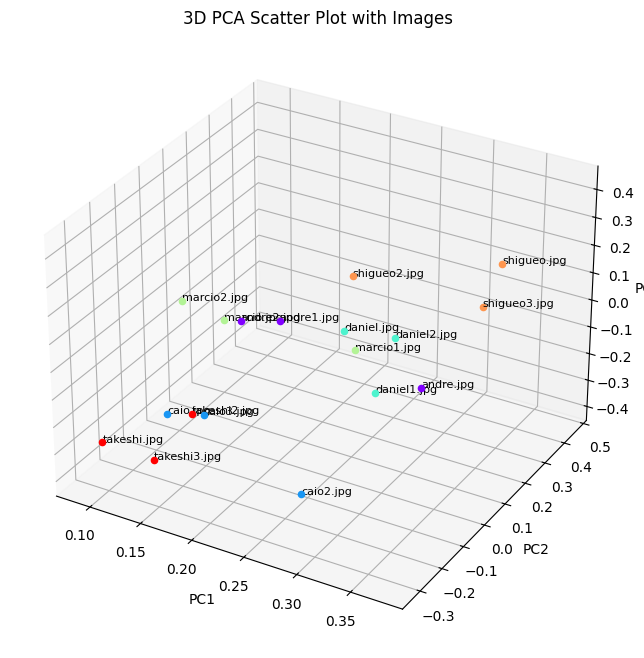

In [22]:
# prompt: Crie um scatterplot 3D com as imagens nos três componentes principais

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import re

# Assuming pca_embeddings and imgs are defined as in the previous code

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(pca_embeddings.shape[0]):
    img_path = imgs[i]
    classe = re.sub(r'\d*.jpg', '', img_path.name)

    # Color by class
    ax.scatter(pca_embeddings.loc[i, 'PC1'], pca_embeddings.loc[i, 'PC2'], pca_embeddings.loc[i, 'PC3'], c=colors[classes_unicas == classe], marker='o')

    # Use ax.text instead of ax.add_artist(AnnotationBbox) for 3D coordinates
    ax.text(pca_embeddings.loc[i,'PC1'], pca_embeddings.loc[i, 'PC2'], pca_embeddings.loc[i, 'PC3'], img_path.name, fontsize=8)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Scatter Plot with Images')

plt.show()

In [23]:
# prompt: Create the same plot above but interactive

import plotly.graph_objects as go
import pandas as pd
import re

# Assuming pca_embeddings and imgs are defined as in the previous code

fig = go.Figure()



for i in range(pca_embeddings.shape[0]):
    img_path = imgs[i]
    classe = re.sub(r'\d*.jpg', '', img_path.name)



    # ... (code to open, crop, and resize the image as before) ...

    fig.add_trace(go.Scatter3d(
        x=[pca_embeddings.loc[i, 'PC1']],
        y=[pca_embeddings.loc[i, 'PC2']],
        z=[pca_embeddings.loc[i, 'PC3']],
        mode='markers',
        name=classe,
        marker=dict(
            size=10,
            color = colors[classes_unicas == classe],
            opacity=0.8
        ),
        text=[classe],  # Use image name as hover text
        hoverinfo='text+x+y+z',  # Show image name and coordinates on hover
        showlegend=False  # Ensure legend is shown
    ))


# Customize layout
fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    title='3D PCA Scatter Plot with Images (Interactive)'
)

fig.show()

In [24]:
# Disconnect runtime
from google.colab import runtime
runtime.unassign()